# MAPPING AND DATA VISUALIZATION OF LAND COVER SURFACE HEAT DYNAMICS IN SOFIA, BULGARIA

This notebook compares two ECOSTRESS Land Surface Temperature (LST) snapshots
over Sofia City Province:

- **14 July 2024, 20:53 local time** – evening acquisition during a summer heat period  
- **02 July 2025, 07:13 local time** – morning acquisition during the July 2025 heatwave  

Urban Atlas 2018 polygons are used as zones for Zonal Statistics in order to:

1. Analyse surface temperature patterns for each acquisition separately;
2. Compare morning vs evening thermal conditions;
3. Explore differences between Urban Atlas land cover / land use classes;
4. Quantify how strongly different land covers contribute to the urban heat environment of Sofia.


# Imports & common setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

csv_2024 = r"D:\Dropbox\01_SOFIA_UNIVERSITY\01_Documents\04_SUMMIT\Paper-Aerospace_research\Outputs\Sofia_Region_only_UA_Stats_table_2024_07_14_20-53.csv"
csv_2025 = r"D:\Dropbox\01_SOFIA_UNIVERSITY\01_Documents\04_SUMMIT\Paper-Aerospace_research\Outputs\Sofia_Region_only_UA_Stats_table_2025_07_02_07-13.csv"

df24_raw = pd.read_csv(csv_2024)
df25_raw = pd.read_csv(csv_2025)

df24_raw.head()


,fid,country,fua_name,fua_code,code_2018,class_2018,prod_date,identifier,perimeter,area,comment,Pop2018,_count,_sum,_mean,_median,_min,_max,Cloud
0,2,BG,Sofia,BG001L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-03,5951-BG001L2,488.941,12667.031,NaN,204,3.0,86.33,28.777,28.71,28.41,29.21,NaN
1,3,BG,Sofia,BG001L2,12100,"Industrial, commercial, public, military and p...",2020-03,21006-BG001L2,3627.668,112198.921,NaN,86,33.0,978.17,29.642,29.57,28.55,30.47,NaN
2,4,BG,Sofia,BG001L2,12100,"Industrial, commercial, public, military and p...",2020-03,21205-BG001L2,3378.059,91977.584,NaN,87,28.0,822.62,29.379,29.38,28.85,29.91,NaN
3,5,BG,Sofia,BG001L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-03,6317-BG001L2,309.931,5944.197,NaN,105,2.0,56.00,28.000,28.00,27.63,28.37,NaN
4,6,BG,Sofia,BG001L2,11100,Continuous urban fabric (S.L. : > 80%),2020-03,1144-BG001L2,318.155,4621.568,NaN,9,2.0,49.60,24.800,24.80,24.63,24.97,NaN


# Harmonise structure & clean data

In [4]:
# In 2024 table Cloud == 1 marks polygons influenced by clouds.
df24 = df24_raw.copy()
df24 = df24[df24["Cloud"] != 1].copy()

In [5]:
#Make UA code string & create broad land-cover groups
def ua_broad_class(code):
    code = str(code)
    if code.startswith("1"):
        return "Artificial surfaces"
    elif code.startswith("2"):
        return "Agricultural areas"
    elif code.startswith("3"):
        return "Natural & semi-natural"
    elif code.startswith("4"):
        return "Wetlands"
    elif code.startswith("5"):
        return "Water bodies"
    else:
        return "Other"

for frame in (df24, df25_raw):
    frame["code_2018"] = frame["code_2018"].astype(str)
    frame["UA_group"] = frame["code_2018"].apply(ua_broad_class)


In [6]:
# Evening 2024: rename _* statistics to common LST_* names
df24 = df24.rename(
    columns={
        "_count": "LST_count",
        "_sum": "LST_sum",
        "_mean": "LST_mean",
        "_median": "LST_median",
        "_min": "LST_min",
        "_max": "LST_max",
    }
).copy()

df24["year"] = 2024
df24["time_of_day"] = "Evening"

# Morning 2025: rename Stat* to same LST_* schema
df25 = df25_raw.rename(
    columns={
        "Statcount": "LST_count",
        "Statsum": "LST_sum",
        "Statmean": "LST_mean",
        "Statmedian": "LST_median",
        "Statmin": "LST_min",
        "Statmax": "LST_max",
    }
).copy()

df25["year"] = 2025
df25["time_of_day"] = "Morning"


# Combine both years into one DataFrame

In [7]:
common_cols = [
    "fid", "country", "fua_name", "fua_code",
    "code_2018", "class_2018", "UA_group",
    "perimeter", "area", "Pop2018",
    "LST_count", "LST_sum", "LST_mean", "LST_median", "LST_min", "LST_max",
    "year", "time_of_day"
]

df_all = pd.concat([df24[common_cols], df25[common_cols]], ignore_index=True)

df_all.head()


,fid,country,fua_name,fua_code,code_2018,class_2018,UA_group,perimeter,area,Pop2018,LST_count,LST_sum,LST_mean,LST_median,LST_min,LST_max,year,time_of_day
0,2,BG,Sofia,BG001L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,Artificial surfaces,488.941,12667.031,204,3.0,86.33,28.777,28.71,28.41,29.21,2024,Evening
1,3,BG,Sofia,BG001L2,12100,"Industrial, commercial, public, military and p...",Artificial surfaces,3627.668,112198.921,86,33.0,978.17,29.642,29.57,28.55,30.47,2024,Evening
2,4,BG,Sofia,BG001L2,12100,"Industrial, commercial, public, military and p...",Artificial surfaces,3378.059,91977.584,87,28.0,822.62,29.379,29.38,28.85,29.91,2024,Evening
3,5,BG,Sofia,BG001L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,Artificial surfaces,309.931,5944.197,105,2.0,56.00,28.000,28.00,27.63,28.37,2024,Evening
4,6,BG,Sofia,BG001L2,11100,Continuous urban fabric (S.L. : > 80%),Artificial surfaces,318.155,4621.568,9,2.0,49.60,24.800,24.80,24.63,24.97,2024,Evening


# 2024 evening analysis
Basic LST distributions (evening)

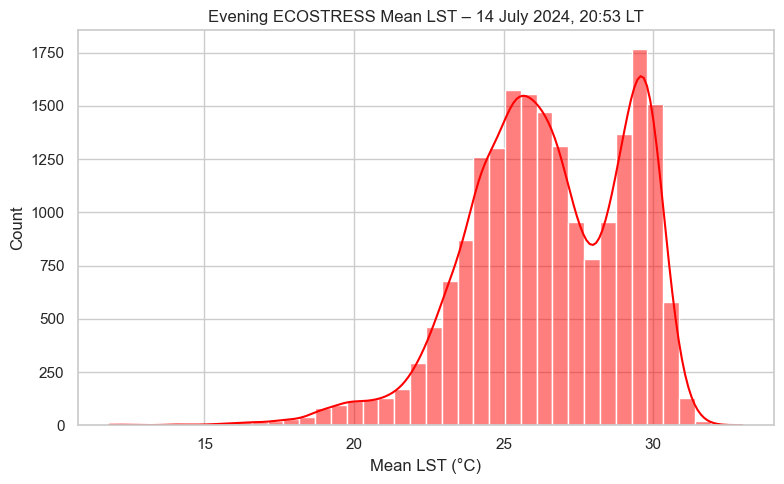

In [8]:
evening = df_all[df_all["time_of_day"] == "Evening"].copy()

plt.figure(figsize=(8,5))
sns.histplot(evening["LST_mean"], bins=40, kde=True, color="red")
plt.xlabel("Mean LST (°C)")
plt.title("Evening ECOSTRESS Mean LST – 14 July 2024, 20:53 LT")
plt.tight_layout()
plt.show()


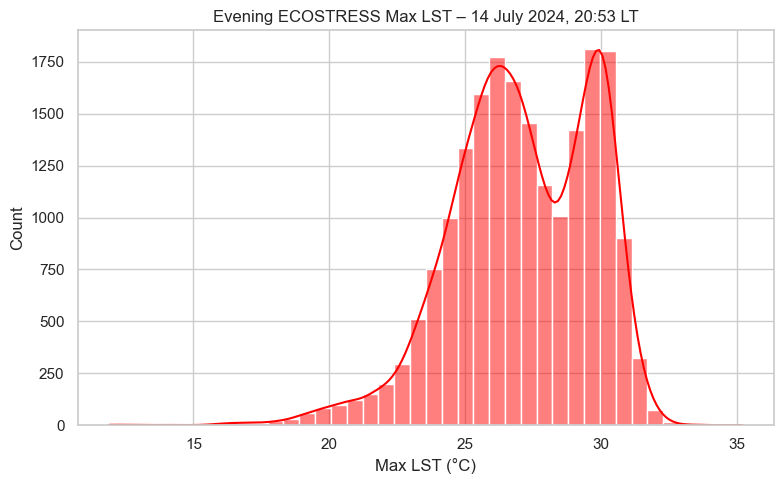

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(evening["LST_max"], bins=40, kde=True, color="red")
plt.xlabel("Max LST (°C)")
plt.title("Evening ECOSTRESS Max LST – 14 July 2024, 20:53 LT")
plt.tight_layout()
plt.show()


# Evening statistics by UA broad group

In [32]:
evening_group_stats = (
    evening
    .groupby("UA_group")
    .agg(
        n_polygons=("fid", "count"),
        total_area_m2=("area", "sum"),
        mean_LST_mean=("LST_mean", "mean"),
        mean_LST_max=("LST_max", "mean"),
    )
    .reset_index()
    .sort_values("mean_LST_mean", ascending=False)
)

evening_group_stats


,UA_group,n_polygons,total_area_m2,mean_LST_mean,mean_LST_max
1,Artificial surfaces,14906,3.262e+08,27.211,27.688
3,Water bodies,105,3.734e+07,25.196,26.323
0,Agricultural areas,3947,6.747e+08,24.442,25.367
2,Natural & semi-natural,725,6.726e+08,23.587,24.516
4,Wetlands,8,2.092e+05,23.206,23.863


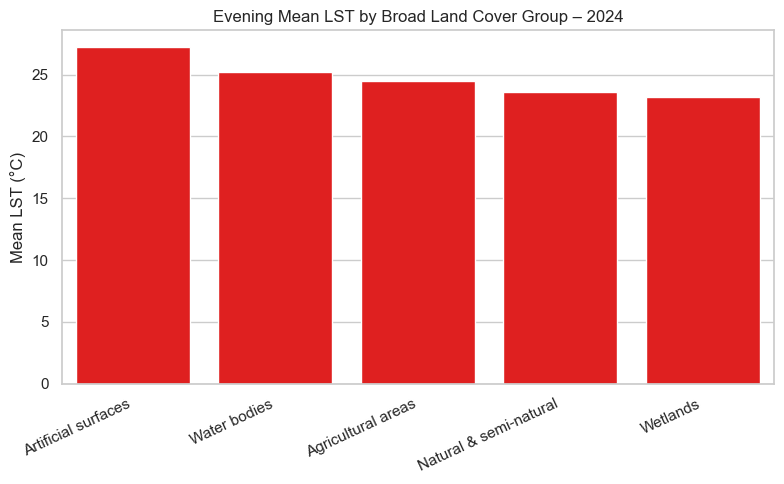

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=evening_group_stats,
    x="UA_group",
    y="mean_LST_mean",
    color='red',
    legend=False
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean LST (°C)")
plt.xlabel("")
plt.title("Evening Mean LST by Broad Land Cover Group – 2024")
plt.tight_layout()
plt.show()


# Evening statistics by detailed UA class

In [37]:
evening_class_stats = (
    evening
    .groupby(["code_2018", "class_2018"])
    .agg(
        n_polygons=("fid", "count"),
        total_area_m2=("area", "sum"),
        mean_LST_mean=("LST_mean", "mean"),
        mean_LST_max=("LST_max", "mean"),
    )
    .reset_index()
)

evening_class_stats.sort_values("mean_LST_mean", ascending=False).head(10)


,code_2018,class_2018,n_polygons,total_area_m2,mean_LST_mean,mean_LST_max
0,11100,Continuous urban fabric (S.L. : > 80%),3139,2.795e+07,28.697,29.072
10,12400,Airports,5,7.216e+06,28.260,31.222
14,14100,Green urban areas,676,2.043e+07,27.972,28.468
6,12100,"Industrial, commercial, public, military and p...",3300,7.534e+07,27.451,28.035
15,14200,Sports and leisure facilities,168,4.595e+06,27.270,27.852
13,13400,Land without current use,347,8.009e+06,27.088,27.586
1,11210,Discontinuous dense urban fabric (S.L. : 50% -...,4746,6.390e+07,27.054,27.491
12,13300,Construction sites,24,3.474e+05,26.989,27.578
9,12230,Railways and associated land,36,5.227e+06,26.652,28.642
8,12220,Other roads and associated land,28,6.670e+07,26.207,27.473


# 2025 morning analysis

# Morning distributions

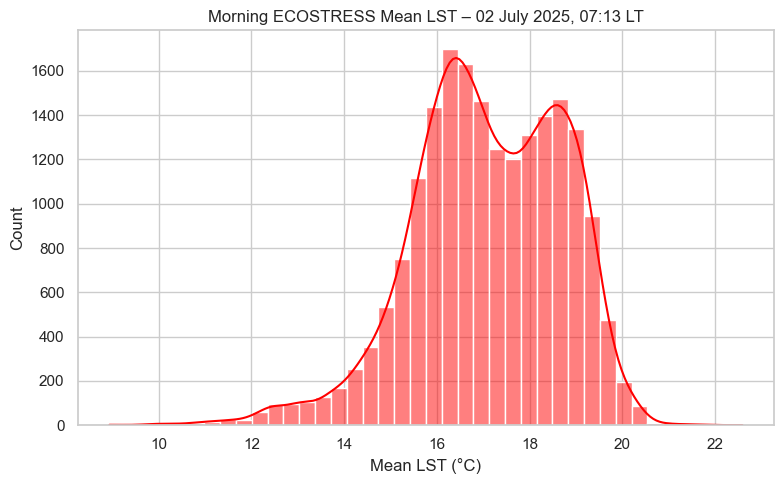

In [38]:
morning = df_all[df_all["time_of_day"] == "Morning"].copy()

plt.figure(figsize=(8,5))
sns.histplot(morning["LST_mean"], bins=40, kde=True, color="red")
plt.xlabel("Mean LST (°C)")
plt.title("Morning ECOSTRESS Mean LST – 02 July 2025, 07:13 LT")
plt.tight_layout()
plt.show()


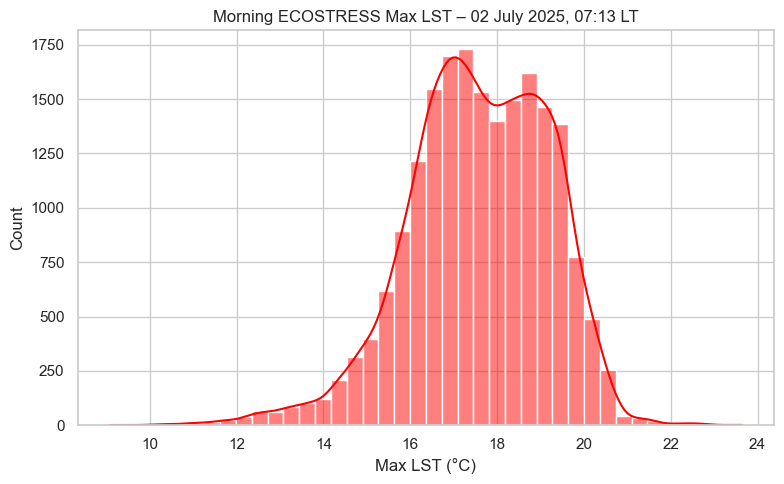

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(morning["LST_max"], bins=40, kde=True, color="red")
plt.xlabel("Max LST (°C)")
plt.title("Morning ECOSTRESS Max LST – 02 July 2025, 07:13 LT")
plt.tight_layout()
plt.show()


# Morning group-level stats

In [40]:
morning_group_stats = (
    morning
    .groupby("UA_group")
    .agg(
        n_polygons=("fid", "count"),
        total_area_m2=("area", "sum"),
        mean_LST_mean=("LST_mean", "mean"),
        mean_LST_max=("LST_max", "mean"),
    )
    .reset_index()
    .sort_values("mean_LST_mean", ascending=False)
)

morning_group_stats


,UA_group,n_polygons,total_area_m2,mean_LST_mean,mean_LST_max
1,Artificial surfaces,14907,3.271e+08,17.477,17.883
3,Water bodies,105,3.734e+07,16.677,17.710
0,Agricultural areas,3947,6.747e+08,15.921,16.620
2,Natural & semi-natural,726,7.622e+08,15.595,16.413
4,Wetlands,8,2.092e+05,15.561,15.895


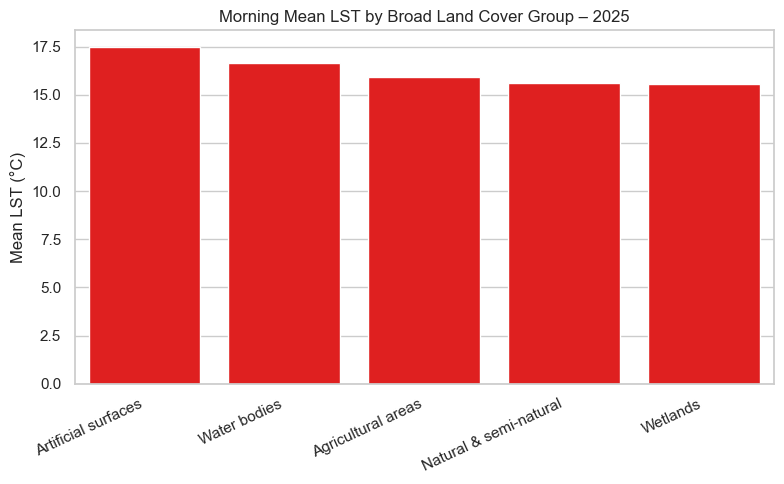

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=morning_group_stats,
    x="UA_group",
    y="mean_LST_mean",
    color = 'red'
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean LST (°C)")
plt.xlabel("")
plt.title("Morning Mean LST by Broad Land Cover Group – 2025")
plt.tight_layout()
plt.show()


# Morning class-level stats

In [48]:
morning_class_stats = (
    morning
    .groupby(["code_2018", "class_2018"])
    .agg(
        n_polygons=("fid", "count"),
        total_area_m2=("area", "sum"),
        mean_LST_mean=("LST_mean", "mean"),
        mean_LST_max=("LST_max", "mean"),
    )
    .reset_index()
)

morning_class_stats.sort_values("mean_LST_mean", ascending=False).head(10)


,code_2018,class_2018,n_polygons,total_area_m2,mean_LST_mean,mean_LST_max
0,11100,Continuous urban fabric (S.L. : > 80%),3139,2.795e+07,18.324,18.693
10,12400,Airports,5,7.216e+06,18.035,19.498
12,13300,Construction sites,24,3.474e+05,17.901,18.365
14,14100,Green urban areas,676,2.043e+07,17.870,18.337
15,14200,Sports and leisure facilities,168,4.595e+06,17.711,18.249
13,13400,Land without current use,347,8.009e+06,17.568,17.999
6,12100,"Industrial, commercial, public, military and p...",3300,7.534e+07,17.499,17.933
1,11210,Discontinuous dense urban fabric (S.L. : 50% -...,4746,6.390e+07,17.392,17.769
7,12210,Fast transit roads and associated land,14,3.149e+06,16.925,18.401
11,13100,Mineral extraction and dump sites,211,1.391e+07,16.843,17.479


# Direct comparison: morning vs evening

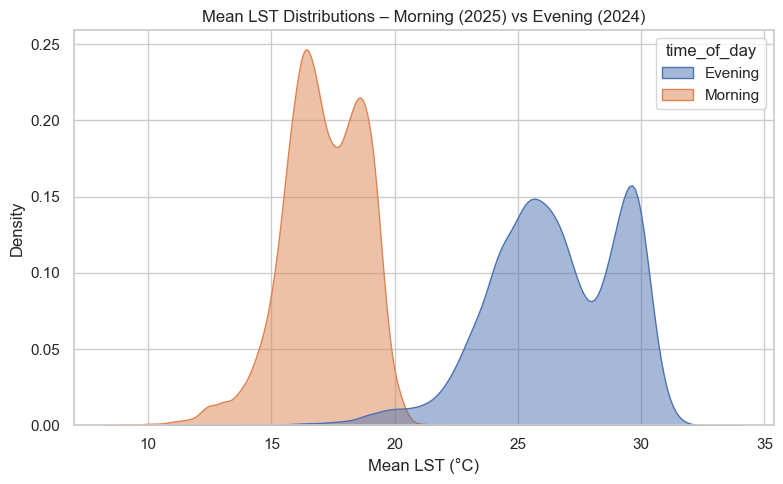

In [49]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_all, x="LST_mean", hue="time_of_day", fill=True, common_norm=False, alpha=0.5)
plt.xlabel("Mean LST (°C)")
plt.title("Mean LST Distributions – Morning (2025) vs Evening (2024)")
plt.tight_layout()
plt.show()


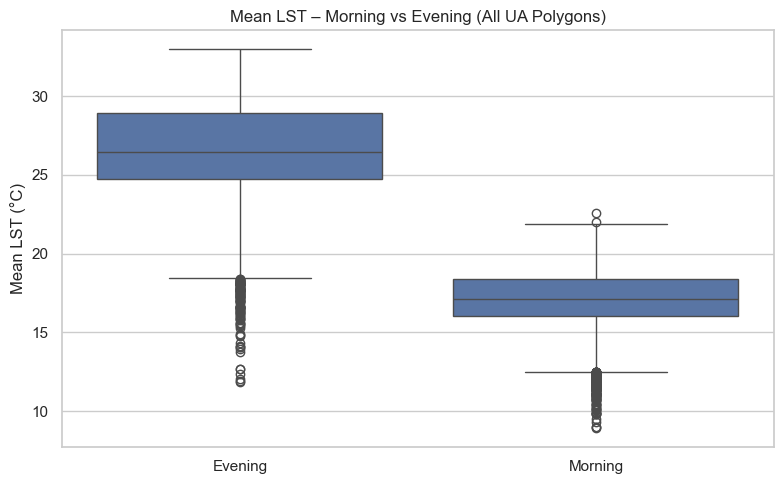

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_all, x="time_of_day", y="LST_mean")
plt.xlabel("")
plt.ylabel("Mean LST (°C)")
plt.title("Mean LST – Morning vs Evening (All UA Polygons)")
plt.tight_layout()
plt.show()


# Comparison by UA broad group

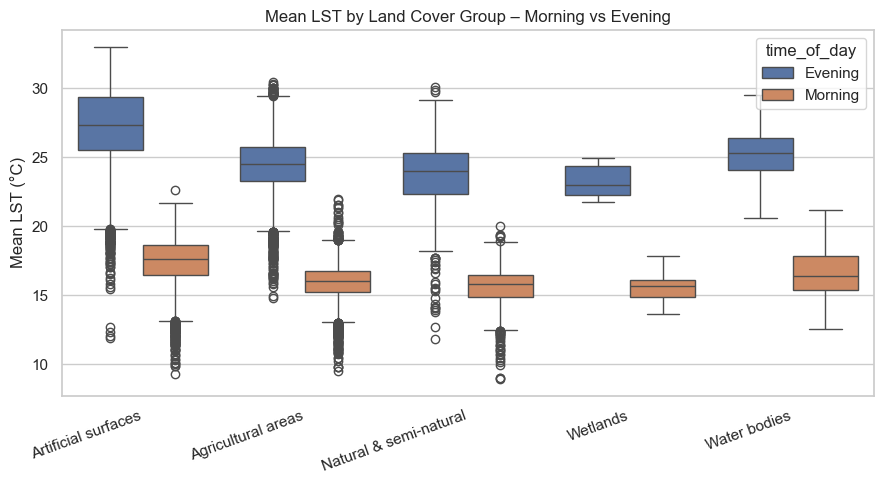

In [51]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_all,
    x="UA_group",
    y="LST_mean",
    hue="time_of_day"
)
plt.xticks(rotation=20, ha="right")
plt.xlabel("")
plt.ylabel("Mean LST (°C)")
plt.title("Mean LST by Land Cover Group – Morning vs Evening")
plt.tight_layout()
plt.show()


# Comparison by UA classes (morning / evening)

In [52]:
class_time_stats = (
    df_all
    .groupby(["code_2018", "class_2018", "time_of_day"])
    .agg(
        n_polygons=("fid", "count"),
        mean_LST_mean=("LST_mean", "mean"),
        mean_LST_max=("LST_max", "mean"),
    )
    .reset_index()
)

class_time_stats.head()


,code_2018,class_2018,time_of_day,n_polygons,mean_LST_mean,mean_LST_max
0,11100,Continuous urban fabric (S.L. : > 80%),Evening,3139,28.697,29.072
1,11100,Continuous urban fabric (S.L. : > 80%),Morning,3139,18.324,18.693
2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,Evening,4746,27.054,27.491
3,11210,Discontinuous dense urban fabric (S.L. : 50% -...,Morning,4746,17.392,17.769
4,11220,Discontinuous medium density urban fabric (S.L...,Evening,1446,25.442,25.902


In [22]:
pivot = (
    class_time_stats
    .pivot(index=["code_2018", "class_2018"], columns="time_of_day", values="mean_LST_mean")
    .reset_index()
)

pivot["delta_evening_minus_morning"] = pivot["Evening"] - pivot["Morning"]
pivot_sorted = pivot.sort_values("delta_evening_minus_morning", ascending=False)

pivot_sorted.head(15)


time_of_day,code_2018,class_2018,Evening,Morning,delta_evening_minus_morning
0,11100,Continuous urban fabric (S.L. : > 80%),28.697,18.324,10.373
10,12400,Airports,28.260,18.035,10.226
14,14100,Green urban areas,27.972,17.870,10.103
6,12100,"Industrial, commercial, public, military and p...",27.451,17.499,9.952
9,12230,Railways and associated land,26.652,16.733,9.919
1,11210,Discontinuous dense urban fabric (S.L. : 50% -...,27.054,17.392,9.662
15,14200,Sports and leisure facilities,27.270,17.711,9.560
8,12220,Other roads and associated land,26.207,16.665,9.543
13,13400,Land without current use,27.088,17.568,9.521
12,13300,Construction sites,26.989,17.901,9.088


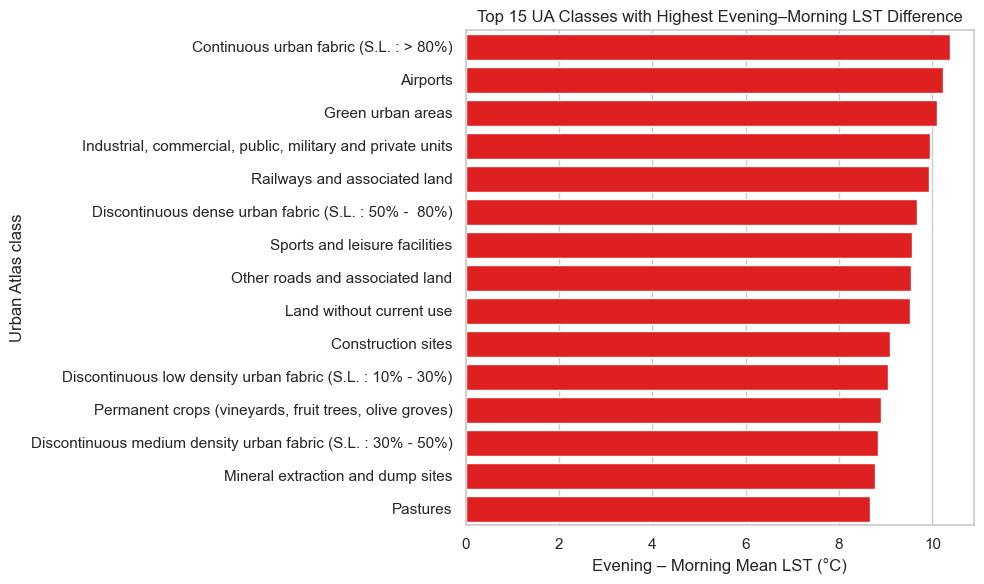

In [55]:
top_delta = pivot_sorted.head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_delta,
    x="delta_evening_minus_morning",
    y="class_2018",
    color = 'red',
)
plt.xlabel("Evening – Morning Mean LST (°C)")
plt.ylabel("Urban Atlas class")
plt.title("Top 15 UA Classes with Highest Evening–Morning LST Difference")
plt.tight_layout()
plt.show()


# Key numbers

In [54]:
# Global means per time of day
summary_time = (
    df_all
    .groupby("time_of_day")
    .agg(
        mean_LST=("LST_mean", "mean"),
        median_LST=("LST_mean", "median"),
        min_LST=("LST_mean", "min"),
        max_LST=("LST_mean", "max"),
    )
)

summary_time


,mean_LST,median_LST,min_LST,max_LST
time_of_day,,,,
Evening,26.51,26.453,11.827,32.977
Morning,17.09,17.090,8.938,22.588


In [25]:
evening_mean = summary_time.loc["Evening", "mean_LST"]
morning_mean = summary_time.loc["Morning", "mean_LST"]
delta_global = evening_mean - morning_mean

print(
    f"On average, evening surface temperatures are {delta_global:.1f} °C higher "
    f"than morning temperatures across all Urban Atlas polygons in Sofia."
)


On average, evening surface temperatures are 9.4 °C higher than morning temperatures across all Urban Atlas polygons in Sofia.
